Detailed explanation: https://medium.com/@alexppppp/how-to-train-an-ensemble-of-convolutional-neural-networks-for-image-classification-8fc69b087d3

GitHub repo: https://github.com/alexppppp/tinyimagenet-classification-ensemble

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import copy
from sklearn.preprocessing import LabelEncoder
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch
from torch.utils.data import DataLoader, random_split
from torchvision.datasets import ImageFolder

if torch.cuda.is_available():
    print('CUDA is available. Working on GPU')
    DEVICE = torch.device('cuda')
else:
    print('CUDA is not available. Working on CPU')
    DEVICE = torch.device('cpu')

CUDA is available. Working on GPU


# Downloading dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nodoubttome/skin-cancer9-classesisic")

print("Path to dataset files:", path)

100%|██████████| 786M/786M [00:08<00:00, 96.8MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/nodoubttome/skin-cancer9-classesisic/versions/1


# Dataset

In [3]:


# transforms_train = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.RandomHorizontalFlip(),
#     transforms.ToTensor(),
#     transforms.Normalize([0.4802, 0.4481, 0.3975], [0.2302, 0.2265, 0.2262]),
#     transforms.RandomErasing(p=0.5, scale=(0.06, 0.08), ratio=(1, 3), value=0, inplace=True)
# ])

# transfortransform_valid_testms_val = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize([0.4802, 0.4481, 0.3975], [0.2302, 0.2265, 0.2262])
# ])

transform_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])

transform_valid_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),
])


train_path = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration", "Train")
test_path = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration", "Test")

full_train_dataset = ImageFolder(train_path, transform=transform_train)
test_dataset = ImageFolder(test_path, transform=transform_valid_test)


train_size = int(0.8 * len(full_train_dataset))  # 80% for training
val_size = len(full_train_dataset) - train_size  # 20% for validation
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

val_dataset.dataset.transform = transform_valid_test


batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print(f"Train batch: {images.shape}, Labels: {labels}")
print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}, Test size: {len(test_dataset)}")

Train batch: torch.Size([32, 3, 64, 64]), Labels: tensor([3, 5, 2, 4, 8, 5, 4, 7, 3, 5, 5, 1, 4, 2, 8, 5, 4, 3, 3, 1, 1, 1, 0, 5,
        3, 5, 3, 8, 4, 3, 3, 4])
Train size: 1791, Val size: 448, Test size: 118


In [4]:
classes = full_train_dataset.classes
classes

['actinic keratosis',
 'basal cell carcinoma',
 'dermatofibroma',
 'melanoma',
 'nevus',
 'pigmented benign keratosis',
 'seborrheic keratosis',
 'squamous cell carcinoma',
 'vascular lesion']

In [5]:
n_classes = len(classes)
n_classes

9

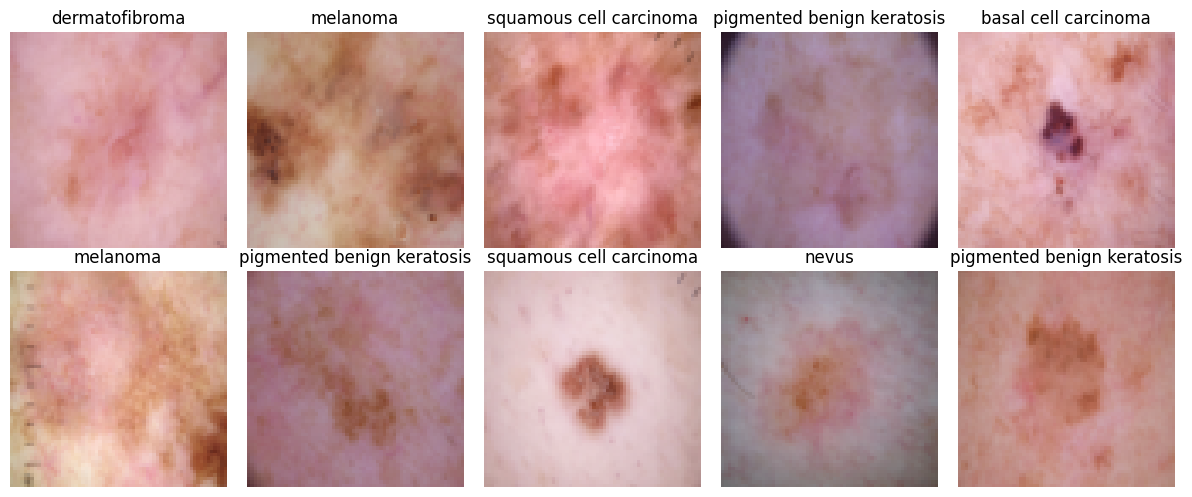

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ImageNet mean and std
mean = np.array([0.5,0.5,0.5])
std = np.array([0.5,0.5,0.5])

# Get a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Show images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].numpy().transpose((1, 2, 0))  # (C, H, W) -> (H, W, C)

    # Unnormalize using ImageNet mean/std
    img = img * std + mean
    img = np.clip(img, 0, 1)  # Ensure pixel values are in [0, 1]

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Functions for training models

In [7]:
def training(model, model_name, num_epochs, train_dataloader, val_dataloader):

    loss_function = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0003)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.33)

    train_loss_array = []
    train_acc_array = []
    val_loss_array = []
    val_acc_array = []
    lowest_val_loss = np.inf
    best_model = None

    for epoch in tqdm(range(num_epochs)):

        print('Epoch: {} | Learning rate: {}'.format(epoch + 1, scheduler.get_lr()))

        for phase in ['train', 'val']:

            epoch_loss = 0
            epoch_correct_items = 0
            epoch_items = 0

            if phase == 'train':
                model.train()
                with torch.enable_grad():
                    for samples, targets in train_dataloader:
                        samples = samples.to(DEVICE)
                        targets = targets.to(DEVICE)

                        optimizer.zero_grad()
                        outputs = model(samples)
                        loss = loss_function(outputs, targets)
                        preds = outputs.argmax(dim=1)
                        correct_items = (preds == targets).float().sum()

                        loss.backward()
                        optimizer.step()

                        epoch_loss += loss.item()
                        epoch_correct_items += correct_items.item()
                        epoch_items += len(targets)
                print(epoch_items)

                train_loss_array.append(epoch_loss / epoch_items)
                train_acc_array.append(epoch_correct_items / epoch_items)

                scheduler.step()

            elif phase == 'val':
                model.eval()
                with torch.no_grad():
                    for samples, targets in val_dataloader:
                        samples = samples.to(DEVICE)
                        targets = targets.to(DEVICE)

                        outputs = model(samples)
                        loss = loss_function(outputs, targets)
                        preds = outputs.argmax(dim=1)
                        correct_items = (preds == targets).float().sum()

                        epoch_loss += loss.item()
                        epoch_correct_items += correct_items.item()
                        epoch_items += len(targets)
                print(epoch_items)

                val_loss_array.append(epoch_loss / epoch_items)
                val_acc_array.append(epoch_correct_items / epoch_items)

                if epoch_loss / epoch_items < lowest_val_loss:
                    lowest_val_loss = epoch_loss / epoch_items
                    torch.save(model.state_dict(), '{}_weights.pth'.format(model_name))
                    best_model = copy.deepcopy(model)
                    print("\t| New lowest val loss for {}: {}".format(model_name, lowest_val_loss))

    return best_model, train_loss_array, train_acc_array, val_loss_array, val_acc_array

In [8]:
def visualize_training_results(train_loss_array,
                               val_loss_array,
                               train_acc_array,
                               val_acc_array,
                               num_epochs,
                               model_name,
                               batch_size):
    fig, axs = plt.subplots(1, 2, figsize=(14,4))
    fig.suptitle("{} training | Batch size: {}".format(model_name, batch_size), fontsize = 16)
    axs[0].plot(list(range(1, num_epochs+1)), train_loss_array, label="train_loss")
    axs[0].plot(list(range(1, num_epochs+1)), val_loss_array, label="val_loss")
    axs[0].legend(loc='best')
    axs[0].set(xlabel='epochs', ylabel='loss')
    axs[1].plot(list(range(1, num_epochs+1)), train_acc_array, label="train_acc")
    axs[1].plot(list(range(1, num_epochs+1)), val_acc_array, label="val_acc")
    axs[1].legend(loc='best')
    axs[1].set(xlabel='epochs', ylabel='accuracy')
    plt.show();

# Training

In [9]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

num_epochs = 5

### Training DenseNet161

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet161_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet161_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/densenet161-8d451a50.pth" to /root/.cache/torch/hub/checkpoints/densenet161-8d451a50.pth


100%|██████████| 110M/110M [00:00<00:00, 163MB/s]
  0%|          | 0/5 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:520: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


Epoch: 1 | Learning rate: [0.0003]
1791
448


 20%|██        | 1/5 [00:33<02:12, 33.21s/it]

...

	| New lowest val loss for DenseNet161: 0.024644012695976665
Epoch: 4 | Learning rate: [3.267e-05]
1791
448


 80%|████████  | 4/5 [02:07<00:31, 31.52s/it]

	| New lowest val loss for DenseNet161: 0.024249552616051266
Epoch: 5 | Learning rate: [9.9e-05]
1791
448


100%|██████████| 5/5 [02:38<00:00, 31.75s/it]

	| New lowest val loss for DenseNet161: 0.02381836622953415


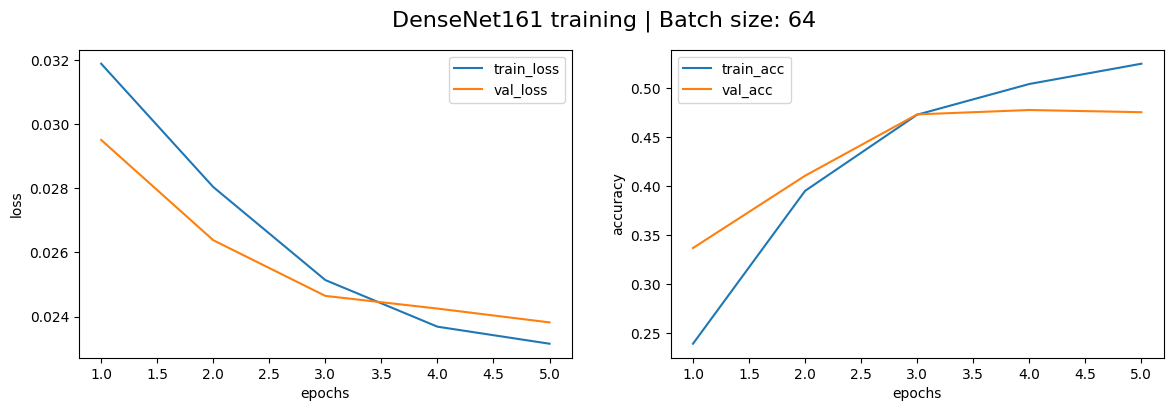


Training results:
	Min val loss 0.0238 was achieved during epoch #5
	Val accuracy during min val loss is 0.4754


In [10]:
model_densenet161 = models.densenet161(pretrained=True)
for param in model_densenet161.parameters():
    param.requires_grad = False
model_densenet161.classifier = torch.nn.Linear(model_densenet161.classifier.in_features, out_features=n_classes)
model_densenet161 = model_densenet161.to(DEVICE)

densenet161_training_results = training(model=model_densenet161,
                                        model_name='DenseNet161',
                                        num_epochs=num_epochs,
                                        train_dataloader=train_dataloader,
                                        val_dataloader=val_dataloader)

model_densenet161, train_loss_array, train_acc_array, val_loss_array, val_acc_array = densenet161_training_results

min_loss = min(val_loss_array)
min_loss_epoch = val_loss_array.index(min_loss)
min_loss_accuracy = val_acc_array[min_loss_epoch]

visualize_training_results(train_loss_array,
                           val_loss_array,
                           train_acc_array,
                           val_acc_array,
                           num_epochs,
                           model_name="DenseNet161",
                           batch_size=64)
print("\nTraining results:")
print("\tMin val loss {:.4f} was achieved during epoch #{}".format(min_loss, min_loss_epoch + 1))
print("\tVal accuracy during min val loss is {:.4f}".format(min_loss_accuracy))

### Training ResNet152

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet152_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet152_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 188MB/s]
  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | Learning rate: [0.0003]
1791
448


 20%|██        | 1/5 [00:30<02:03, 30.85s/it]

...

	| New lowest val loss for ResNet152: 0.023492797410913875
Epoch: 4 | Learning rate: [3.267e-05]
1791
448


 80%|████████  | 4/5 [02:02<00:30, 30.71s/it]

	| New lowest val loss for ResNet152: 0.0230167242033141
Epoch: 5 | Learning rate: [9.9e-05]
1791
448


100%|██████████| 5/5 [02:33<00:00, 30.77s/it]

	| New lowest val loss for ResNet152: 0.022835161004747664


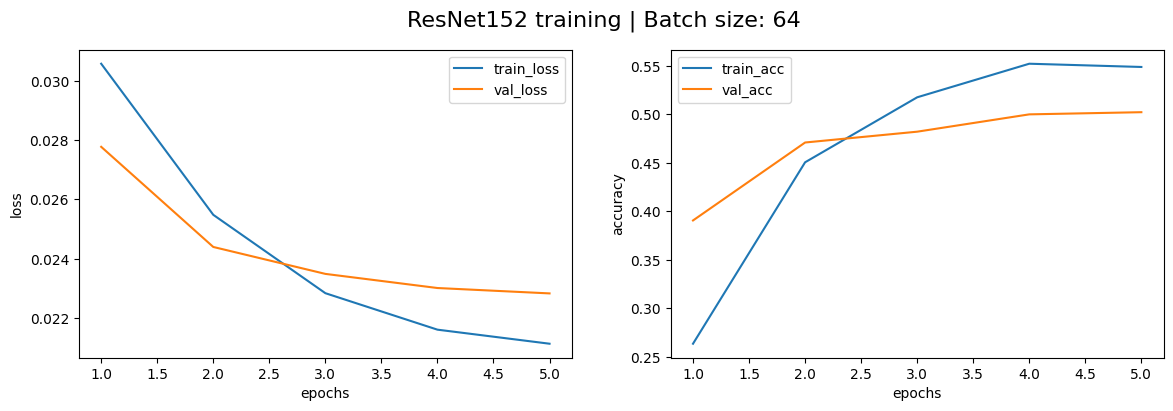


Training results:
	Min val loss 0.0228 was achieved during epoch #5
	Val accuracy during min val loss is 0.5022


In [11]:
model_resnet152 = models.resnet152(pretrained=True)
for param in model_resnet152.parameters():
    param.requires_grad = False
model_resnet152.fc = torch.nn.Linear(model_resnet152.fc.in_features, n_classes)
model_resnet152 = model_resnet152.to(DEVICE)

resnet152_training_results = training(model=model_resnet152,
                                      model_name='ResNet152',
                                      num_epochs=num_epochs,
                                      train_dataloader=train_dataloader,
                                      val_dataloader=val_dataloader)

model_resnet152, train_loss_array, train_acc_array, val_loss_array, val_acc_array = resnet152_training_results

min_loss = min(val_loss_array)
min_loss_epoch = val_loss_array.index(min_loss)
min_loss_accuracy = val_acc_array[min_loss_epoch]

visualize_training_results(train_loss_array,
                           val_loss_array,
                           train_acc_array,
                           val_acc_array,
                           num_epochs,
                           model_name="ResNet152",
                           batch_size=64)
print("\nTraining results:")
print("\tMin val loss {:.4f} was achieved during epoch #{}".format(min_loss, min_loss_epoch + 1))
print("\tVal accuracy during min val loss is {:.4f}".format(min_loss_accuracy))

### Training VGG19

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_BN_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_BN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19_bn-c79401a0.pth" to /root/.cache/torch/hub/checkpoints/vgg19_bn-c79401a0.pth


100%|██████████| 548M/548M [00:05<00:00, 113MB/s]
  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | Learning rate: [0.0003]
1791
448


 20%|██        | 1/5 [01:00<04:00, 60.22s/it]

...

	| New lowest val loss for VGG19_bn: 0.023560133895703723
Epoch: 4 | Learning rate: [3.267e-05]
1791
448


 80%|████████  | 4/5 [02:56<00:42, 42.36s/it]

	| New lowest val loss for VGG19_bn: 0.02346095017024449
Epoch: 5 | Learning rate: [9.9e-05]
1791
448


100%|██████████| 5/5 [03:39<00:00, 43.96s/it]

	| New lowest val loss for VGG19_bn: 0.023420735129288266


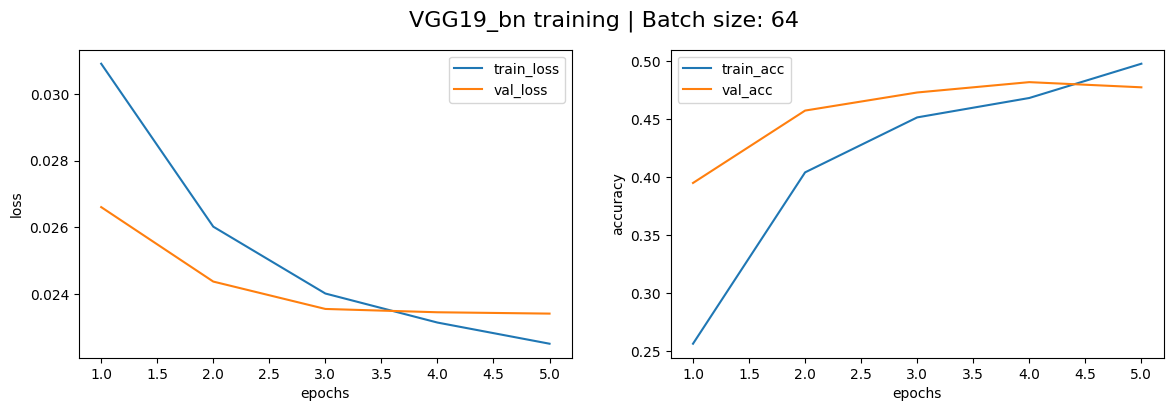


Training results:
	Min val loss 0.0234 was achieved during epoch #5
	Val accuracy during min val loss is 0.4777


In [12]:
model_vgg19_bn = models.vgg19_bn(pretrained=True)
for param in model_vgg19_bn.parameters():
    param.requires_grad = False
model_vgg19_bn.classifier[6] = torch.nn.Linear(in_features=model_vgg19_bn.classifier[6].in_features, out_features=n_classes)
model_vgg19_bn = model_vgg19_bn.to(DEVICE)

vgg19_bn_training_results = training(model=model_vgg19_bn,
                                     model_name='VGG19_bn',
                                     num_epochs=num_epochs,
                                     train_dataloader=train_dataloader,
                                     val_dataloader=val_dataloader)

model_vgg19_bn, train_loss_array, train_acc_array, val_loss_array, val_acc_array = vgg19_bn_training_results

min_loss = min(val_loss_array)
min_loss_epoch = val_loss_array.index(min_loss)
min_loss_accuracy = val_acc_array[min_loss_epoch]

visualize_training_results(train_loss_array,
                           val_loss_array,
                           train_acc_array,
                           val_acc_array,
                           num_epochs,
                           model_name="VGG19_bn",
                           batch_size=64)
print("\nTraining results:")
print("\tMin val loss {:.4f} was achieved during epoch #{}".format(min_loss, min_loss_epoch + 1))
print("\tVal accuracy during min val loss is {:.4f}".format(min_loss_accuracy))

### Training ensemble

In [13]:
# In case we want to use saved weights

# model_vgg19_bn = models.vgg19_bn(pretrained = False)
# model_vgg19_bn.classifier[6] = torch.nn.Linear(in_features=4096, out_features=200)

# model_resnet152 = models.resnet152(pretrained = False)
# model_resnet152.fc = torch.nn.Linear(in_features=2048, out_features=200)

# model_densenet161 = models.densenet161(pretrained = False)
# model_densenet161.classifier = torch.nn.Linear(in_features=2208, out_features=200)

# model_vgg19_bn.load_state_dict(torch.load('VGG19_bn_weights.pth'))
# model_resnet152.load_state_dict(torch.load('ResNet152_weights.pth'))
# model_densenet161.load_state_dict(torch.load('DenseNet161_weights.pth'))

In [14]:
class EnsembleModel(nn.Module):
    def __init__(self, modelA, modelB, modelC):
        super().__init__()
        self.modelA = modelA
        self.modelB = modelB
        self.modelC = modelC
        self.classifier = nn.Linear(9 * 3, 9)

    def forward(self, x):
        x1 = self.modelA(x)
        x2 = self.modelB(x)
        x3 = self.modelC(x)
        x = torch.cat((x1, x2, x3), dim=1)
        out = self.classifier(x)
        return out

ensemble_model = EnsembleModel(model_densenet161, model_resnet152, model_vgg19_bn)

for param in ensemble_model.parameters():
    param.requires_grad = False

for param in ensemble_model.classifier.parameters():
    param.requires_grad = True

ensemble_model = ensemble_model.to(DEVICE)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | Learning rate: [0.0003]
1791
448


  5%|▌         | 1/20 [00:39<12:21, 39.01s/it]

	| New lowest val loss for Ensemble: 0.03392406925559044
Epoch: 2 | Learning rate: [0.0003]
1791
448


 10%|█         | 2/20 [01:58<18:54, 63.01s/it]

...

448
Epoch: 19 | Learning rate: [1.27855328931e-07]
1791


 95%|█████████▌| 19/20 [13:49<00:34, 34.28s/it]

448
Epoch: 20 | Learning rate: [3.874403907e-07]
1791


100%|██████████| 20/20 [14:19<00:00, 42.96s/it]

448


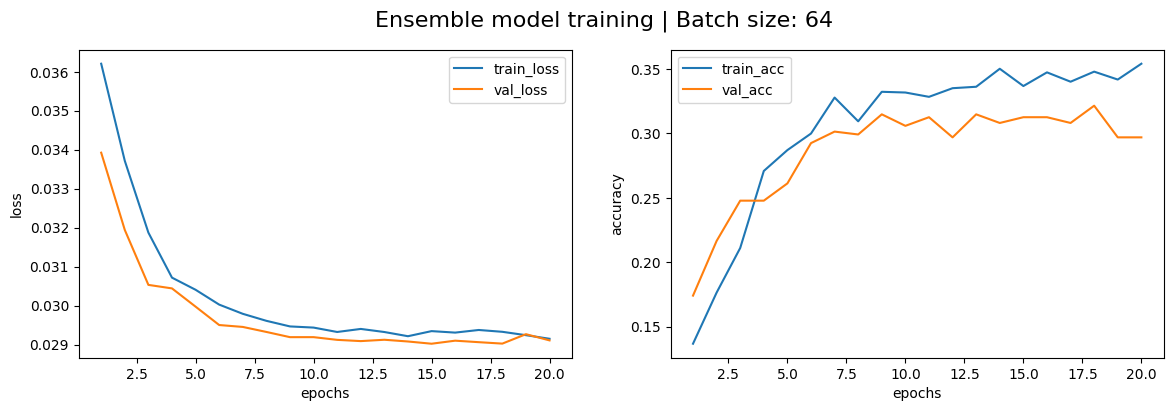


Training results:
	Min val loss 0.0290 was achieved during iteration #15
	Val accuracy during min val loss is 0.3125


In [15]:
ensemble_training_results = training(model=ensemble_model,
                                     model_name='Ensemble',
                                     num_epochs=20,
                                     train_dataloader=train_dataloader,
                                     val_dataloader=val_dataloader)

ensemble_model, train_loss_array, train_acc_array, val_loss_array, val_acc_array = ensemble_training_results

min_loss = min(val_loss_array)
min_loss_iteration = val_loss_array.index(min_loss)
min_loss_accuracy = val_acc_array[min_loss_iteration]

visualize_training_results(train_loss_array,
                           val_loss_array,
                           train_acc_array,
                           val_acc_array,
                           num_epochs=20,
                           model_name="Ensemble model",
                           batch_size=64)
print("\nTraining results:")
print("\tMin val loss {:.4f} was achieved during iteration #{}".format(min_loss, min_loss_iteration + 1))
print("\tVal accuracy during min val loss is {:.4f}".format(min_loss_accuracy))